✅ Added /home/amoleri/PycharmProjects/FederatedFactory/src to path
✅ Models imported successfully
🚀 Found 5 unique latest checkpoints.

--- [1/5] Processing: cifar/silos/client_0/class_0/training-state-0005038.pt ---
   🕵️  Detected: 32x32 | Ch: 128 | Depth: 4 ([1, 2, 2, 2])


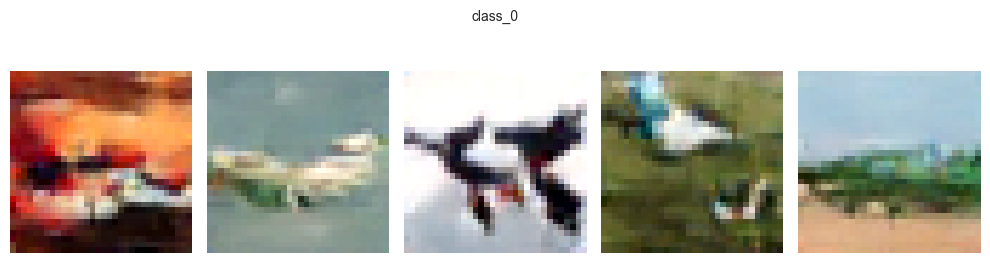

--- [2/5] Processing: fed_isic2019/silos/client_0/class_0/training-state-0001502.pt ---
   🕵️  Detected: 128x128 | Ch: 64 | Depth: 4 ([1, 2, 2, 2])


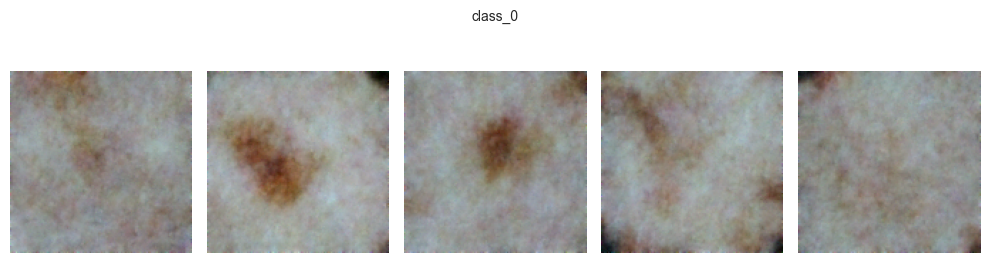

--- [3/5] Processing: medmnist_bloodmnist/silos/client_0/class_0/training-state-0005007.pt ---
   🕵️  Detected: 32x32 | Ch: 128 | Depth: 4 ([1, 2, 2, 2])


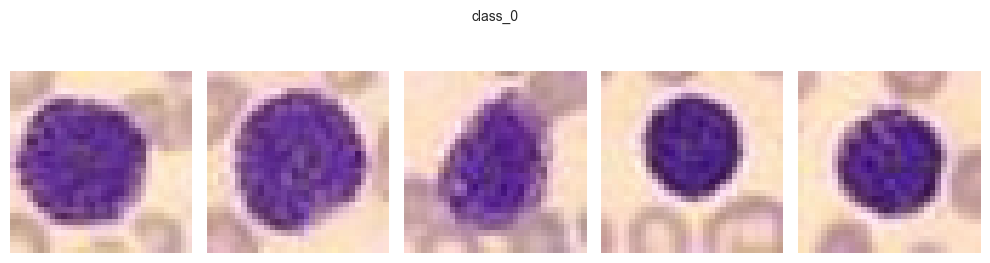

--- [4/5] Processing: medmnist_pathmnist/silos/client_0/class_0/training-state-0005038.pt ---
   🕵️  Detected: 32x32 | Ch: 128 | Depth: 4 ([1, 2, 2, 2])


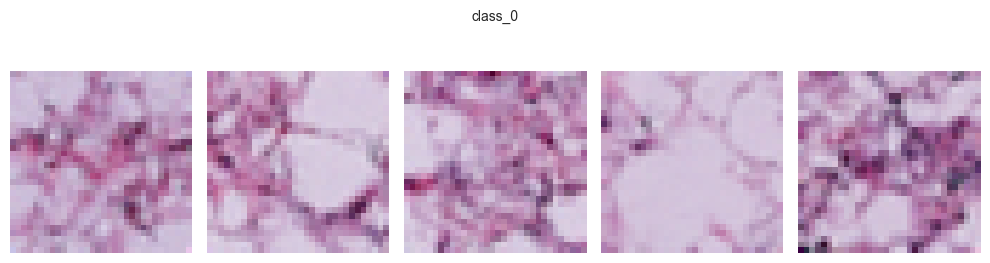

--- [5/5] Processing: medmnist_retinamnist/silos/client_0/class_0/training-state-0005007.pt ---
   🕵️  Detected: 32x32 | Ch: 128 | Depth: 4 ([1, 2, 2, 2])


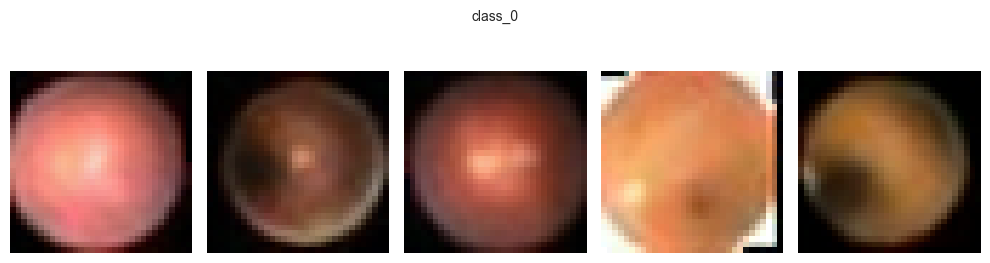

In [38]:
# %% [markdown]
# # Checkpoint Validation & Generation Scanner
#
# This notebook scans the `commands/checkpoints/` directory.
# For every checkpoint found, it:
# 1. **inspects the weights** to detect the exact architecture (Res, Depth, Channels).
# 2. Loads the model with the detected config.
# 3. Generates 5 synthetic images to verify the frozen core is working.

# %%
import sys
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import re

# ==========================================
# 1. SETUP PATHS
# ==========================================
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))
    print(f"✅ Added {PROJECT_ROOT}/src to path")
else:
    raise FileNotFoundError("Could not find 'src' directory. Run this from project root.")

try:
    from models.diffusion import DiT, DiffusionConfig, rectified_flow_sampler
    print("✅ Models imported successfully")
except ImportError as e:
    print(f"❌ Failed to import models: {e}")
    print("Ensure requirements (EDM2 submodules) are installed.")

# %%
# ==========================================
# 2. SMART DETECTION & UTILITIES
# ==========================================

def detect_model_params(state_dict):
    """
    Analyzes the state_dict keys to reverse-engineer the model configuration.
    Returns: (resolution, channels, channel_mult_list)
    """
    # 1. Extract all resolutions from encoder block names
    # Pattern looks like: "edm_net.unet.enc.128x128_block0..."
    res_pattern = re.compile(r"enc\.(\d+)x\d+_block")
    resolutions = set()

    # 2. Search for Channel Width (Base Dim)
    # We look for the first convolution of the highest resolution block
    base_channels = 128 # Default fallback
    found_channels = False

    keys = list(state_dict.keys())
    for k in keys:
        # Detect Resolution
        match = res_pattern.search(k)
        if match:
            resolutions.add(int(match.group(1)))

    if not resolutions:
        # Fallback for non-standard naming
        return 32, 128, [1, 2, 2, 2]

    # Sort resolutions to find Max (Image Size) and Count (Depth)
    sorted_res = sorted(list(resolutions), reverse=True)
    img_resolution = sorted_res[0]
    depth = len(sorted_res)

    # Detect Base Channels from the highest res block
    # Key example: ...enc.128x128_block0.conv_res0.weight -> Shape [Out, In, k, k]
    # For the first block, OutChannels == EmbedDim
    target_key_part = f"enc.{img_resolution}x{img_resolution}_block0.conv_res0.weight"

    for k, v in state_dict.items():
        if target_key_part in k:
            base_channels = v.shape[0]
            found_channels = True
            break

    # Construct Multipliers based on Depth
    # Depth 2 -> [1, 2]
    # Depth 3 -> [1, 2, 2]
    # Depth 4 -> [1, 2, 2, 2]
    mults = [1] + [2] * (depth - 1)

    return img_resolution, base_channels, mults

def infer_input_channels(ckpt_path):
    path_str = str(ckpt_path).lower()
    if "medmnist" in path_str and any(x in path_str for x in ["organ", "oct", "pneumonia", "tissue", "breast"]):
        return 1
    return 3

def show_images(tensors, title="Generated"):
    tensors = (tensors.detach().cpu() + 1) / 2.0
    tensors = tensors.clamp(0, 1)

    n = len(tensors)
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2.5))
    if n == 1: axes = [axes]

    for i, ax in enumerate(axes):
        img = tensors[i].permute(1, 2, 0).numpy()
        if img.shape[2] == 1:
            img = img.squeeze(2)
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.axis("off")

    fig.suptitle(title, fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

# %%
# ==========================================
# 3. SCANNER & GENERATOR
# ==========================================

def adjust_state_dict(ckpt_state_dict, model_state_dict):
    new_state_dict = {}
    model_has_wrapper = any(k.startswith("edm_net.") for k in model_state_dict.keys())

    for k, v in ckpt_state_dict.items():
        if k in ["stds", "emas", "loss_fn", "optimizer", "state"]: continue

        clean_k = k.replace("module.", "").replace("_orig_mod.", "")

        if model_has_wrapper and not clean_k.startswith("edm_net."):
            new_key = f"edm_net.{clean_k}"
        elif not model_has_wrapper and clean_k.startswith("edm_net."):
            new_key = clean_k.replace("edm_net.", "")
        else:
            new_key = clean_k

        if new_key in model_state_dict:
            new_state_dict[new_key] = v

    return new_state_dict

def scan_and_generate():
    possible_paths = [PROJECT_ROOT / "commands" / "checkpoints", PROJECT_ROOT / "checkpoints"]
    ckpt_root = next((p for p in possible_paths if p.exists()), None)

    if not ckpt_root:
        print("❌ No checkpoint directory found.")
        return

    all_checkpoints = list(ckpt_root.rglob("*.pt"))
    latest_checkpoints = {}

    for ckpt in all_checkpoints:
        folder = ckpt.parent
        match = re.search(r'(\d+)', ckpt.name)
        current_val = int(match.group(1)) if match else 0
        if folder not in latest_checkpoints:
            latest_checkpoints[folder] = (current_val, ckpt)
        else:
            if current_val > latest_checkpoints[folder][0]:
                latest_checkpoints[folder] = (current_val, ckpt)

    checkpoints = sorted([v[1] for v in latest_checkpoints.values()])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"🚀 Found {len(checkpoints)} unique latest checkpoints.\n")

    for i, ckpt in enumerate(checkpoints):
        rel_path = ckpt.relative_to(ckpt_root)
        print(f"--- [{i+1}/{len(checkpoints)}] Processing: {rel_path} ---")

        try:
            # 1. Load Raw Data
            chkpt_data = torch.load(ckpt, map_location=device)
            raw_state_dict = None
            if isinstance(chkpt_data, dict):
                if "net" in chkpt_data: raw_state_dict = chkpt_data["net"]
                elif "ema" in chkpt_data: raw_state_dict = chkpt_data["ema"]
                elif "state_dict" in chkpt_data: raw_state_dict = chkpt_data["state_dict"]
                elif "model" in chkpt_data: raw_state_dict = chkpt_data["model"]
            if raw_state_dict is None: raw_state_dict = chkpt_data

            # 2. Detect Config from Weights
            res, dim, mults = detect_model_params(raw_state_dict)
            in_ch = infer_input_channels(ckpt)

            print(f"   🕵️  Detected: {res}x{res} | Ch: {dim} | Depth: {len(mults)} ({mults})")

            cfg = DiffusionConfig(
                in_ch=in_ch,
                embed_dim=dim,
                channel_mult=mults,
                dropout=0.0, # Dropout doesn't affect weight loading
                img_resolution=res,
                num_classes=0
            )

            # 3. Init & Load
            model = DiT(cfg).to(device)
            clean_state_dict = adjust_state_dict(raw_state_dict, model.state_dict())

            missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

            if len(missing) > 0:
                print(f"   ⚠️  Missing keys (partial load): {len(missing)}")
                # If still high missing count, architecture is likely fundamentally mismatched
                if len(missing) > 20:
                     print("      ❌ Architecture mismatch persists. Skipping generation.")
                     continue

            # 4. Generate
            model.eval()
            with torch.no_grad():
                samples = rectified_flow_sampler(
                    model, n=5, shape=(cfg.in_ch, cfg.img_resolution, cfg.img_resolution), steps=20, device=device
                )

            show_images(samples, title=f"{rel_path.parent.name}")

            del model, samples
            if device.type == 'cuda': torch.cuda.empty_cache()

        except Exception as e:
            print(f"❌ Error processing {ckpt.name}: {e}")

if __name__ == "__main__":
    scan_and_generate()